<a href="https://colab.research.google.com/github/nikovido/telecomx-churnprediction-alura-one/blob/main/TelecomX_parte2_proyecto_Alura_ONE_G9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Parte 2: Predicción de Cancelación (Churn)

Modelos de predicción sobre churn de clientes en TelecomX.

## 📚 Diccionario de datos del dataset

- customerID: número de identificación único de cada cliente
- Churn: si el cliente dejó o no la empresa
- gender: género (masculino y femenino)
- SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- Partner: si el cliente tiene o no una pareja
- Dependents: si el cliente tiene o no dependientes
- tenure: meses de contrato del cliente
- PhoneService: suscripción al servicio telefónico
- MultipleLines: suscripción a más de una línea telefónica
- InternetService: suscripción a un proveedor de internet
- OnlineSecurity: suscripción adicional de seguridad en línea
- OnlineBackup: suscripción adicional de respaldo en línea
- DeviceProtection: suscripción adicional de protección del dispositivo
- TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
- StreamingTV: suscripción de televisión por cable
- StreamingMovies: suscripción de streaming de películas
- Contract: tipo de contrato
- PaperlessBilling: si el cliente prefiere recibir la factura en línea
- PaymentMethod: forma de pago
- Charges.Monthly: total de todos los servicios del cliente por mes
- Charges.Total: total gastado por el cliente

## 📌 Extracción

***Nota***: Vamos a volver a cargar los datos originales, ya que las transformaciones que realizamos en la parte 1 del proyecto no son adecuadas para los modelos de machine-learning que vamos a realizar en este proyecto.

In [91]:
# Importamos pandas, abrimos el json desde url y lo cargamos en un df

import pandas as pd

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

datos_raw = pd.read_json(url)
datos_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


- Detectamos que hay columnas anidadas. Vamos a importar los datos con ***requests*** para manejar errores de link y luego normalizar el json con ***json_normalize*** antes de cargarlo a un df.

In [92]:
import pandas as pd
import requests
import json

# 1. Definimos la URL del json
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

try:
    # 2. Hacemos la petición (request) para obtener el texto crudo
    print("⏳ Descargando datos...")
    response = requests.get(url)
    response.raise_for_status() # Esto nos avisa si el link está roto (error 404, etc.)

    # 3. Convertimos ese texto a un objeto de Python
    data = response.json()
    print("✅ Datos descargados y leídos correctamente.")

    # 4. Normalizamos (aplanamos) el JSON. json_normalize convierte estructuras anidadas en columnas separadas.
    df = pd.json_normalize(data)

    # 5. Mostramos las primeras filas y las columnas resultantes
    print(f"\nEl DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    print("\n--- Primeras 5 filas ---")
    print(df.head())

except requests.exceptions.HTTPError as e:
    print(f"❌ Error al descargar el archivo: {e}")
except json.JSONDecodeError:
    print(f"❌ El contenido descargado no es un JSON válido.")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

⏳ Descargando datos...
✅ Datos descargados y leídos correctamente.

El DataFrame tiene 7267 filas y 21 columnas.

--- Primeras 5 filas ---
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Ye

## 🔧 Transformación

### Verificación de inconsistencias

In [93]:
# Priumer analisis exploratorio
df.tail(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


- Valores repetidos: vamos a verificar si hayt registros duplicados en el df.

In [94]:
print(f'Registros duplicados: {df.duplicated().sum()}.')

Registros duplicados: 0.


- Valors nulos: verificamos si hay valores nulos.

In [95]:
print(f'Registros núlos: {df.isnull().sum()}.')

Registros núlos: customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64.


- Valores vacios o en blanco.

In [96]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


### Manejo de inconsistencias

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

- Lo primero que detectamos es que la columna account.Charges.Total esta como string en vez de float64. Vamos a arreglarlo.


In [98]:
# Convertimos la columna forzando los errores a NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificamos cuántos valores se convirtieron en NaN
nulos = df['account.Charges.Total'].isna().sum()
print(f"Se encontraron {nulos} valores que no eran números y se convirtieron a NaN.")

Se encontraron 11 valores que no eran números y se convirtieron a NaN.


In [99]:
# Como son pocos los valores nulos, vamos a deshecharlos para no alterar el linaje de datos
df = df.dropna()

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

- Ahora solo nos queda la columna ***Churn*** con valores vacios. Vamos a eliminarlos.

In [101]:
df = df[df['Churn'].str.strip() != '']
print('Números de filas luego de eliminar vacios en churn: ', len(df))

Números de filas luego de eliminar vacios en churn:  7032


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

### Estandarización y transformación de datos

- Cambiamos el nombre de las columnas para facilitar la lectura, especialmente de los stakeholders no técnicos.

In [103]:
columnas = {
    'customerID': 'id',
    'Churn': 'Churn',
    'customer.gender': 'Gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'Tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',
    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'Charges.Monthly',
    'account.Charges.Total': 'Charges.Total',
    }

df.rename(columns=columnas, inplace=True)
df.head()

,id,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


- Vamos a inspeccionar los valores unicos de cada columna, para detectar posibles desvios o errores de carga. Vamos a seleccionar las columnas categoricas y explorarlas una a una.

In [104]:
columnas_categoricas = list(df.columns[1:19]) # No incluimos el ID, porque son todos valores unicos...

columnas_categoricas

['Churn',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [105]:
# Sacamos tiempo_contrato (tenure) porque son valores diferentes..
columnas_categoricas.remove('Tenure')
columnas_categoricas

['Churn',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [106]:
# Verificación de valores unicos de cada columna categorica

for col in columnas_categoricas:
    print(f"Valores únicos en la columna {col}: {df[col].unique()}.")

Valores únicos en la columna Churn: ['No' 'Yes'].
Valores únicos en la columna Gender: ['Female' 'Male'].
Valores únicos en la columna SeniorCitizen: [0 1].
Valores únicos en la columna Partner: ['Yes' 'No'].
Valores únicos en la columna Dependents: ['Yes' 'No'].
Valores únicos en la columna PhoneService: ['Yes' 'No'].
Valores únicos en la columna MultipleLines: ['No' 'Yes' 'No phone service'].
Valores únicos en la columna InternetService: ['DSL' 'Fiber optic' 'No'].
Valores únicos en la columna OnlineSecurity: ['No' 'Yes' 'No internet service'].
Valores únicos en la columna OnlineBackup: ['Yes' 'No' 'No internet service'].
Valores únicos en la columna DeviceProtection: ['No' 'Yes' 'No internet service'].
Valores únicos en la columna TechSupport: ['Yes' 'No' 'No internet service'].
Valores únicos en la columna StreamingTV: ['Yes' 'No' 'No internet service'].
Valores únicos en la columna StreamingMovies: ['No' 'Yes' 'No internet service'].
Valores únicos en la columna Contract: ['One ye

- No se observan grandes irregularidades. Pero vamos a unificar el formato de las columnas. Primero nos encargamos de las columnas que solo tienen Yes No.

In [107]:
# 1. Definimos el mapeo  para Yes / No - 1 / 0
mapa_booleano = {'Yes': 1, 'No': 0}

# 2. Identificamos las columnas que contienen 'Yes' y 'No'
#    (excluimos las que tienen 3 opciones como "No internet service" y )

cols_yes_no = []
for col in df.columns:
    # Revisamos si es tipo objeto (texto/string) y si sus valores únicos son solo Yes/No o nulo
    if df[col].dtype == 'object':
        unique_vals = set(df[col].unique())

        # Si los valores son subconjunto de Yes No, No phone service y No internet service
        if unique_vals.issubset({'Yes', 'No'}):
            cols_yes_no.append(col)

print(f"Columnas detectadas para convertir: {cols_yes_no}")

# 3. Aplicamos el reemplazo
for col in cols_yes_no:
    df[col] = df[col].map(mapa_booleano)


df.head()

Columnas detectadas para convertir: ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


,id,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


- Continuamos con las columnas restantes

In [108]:
# 1. Definimos el mapeo con un diccionario para aplicar los cambios
mapa = {'Yes': 1, 'No': 0,
        'No phone service': 0, 'No internet service': 0,
        }

# 2. Identificamos las columnas a normalizar
cols_normalizar = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV',
                   'StreamingMovies']




# 3. Aplicamos el reemplazo
for col in cols_normalizar:
    df[col] = df[col].map(mapa)


print(f"Columnas detectadas para convertir: {len(cols_normalizar)}")


df.head()

Columnas detectadas para convertir: 7


,id,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [109]:
# Verificación de valores unicos de cada columna categorica

for col in columnas_categoricas:
    print(f"Valores únicos en la columna {col}: {df[col].unique()}.")

Valores únicos en la columna Churn: [0 1].
Valores únicos en la columna Gender: ['Female' 'Male'].
Valores únicos en la columna SeniorCitizen: [0 1].
Valores únicos en la columna Partner: [1 0].
Valores únicos en la columna Dependents: [1 0].
Valores únicos en la columna PhoneService: [1 0].
Valores únicos en la columna MultipleLines: [0 1].
Valores únicos en la columna InternetService: ['DSL' 'Fiber optic' 'No'].
Valores únicos en la columna OnlineSecurity: [0 1].
Valores únicos en la columna OnlineBackup: [1 0].
Valores únicos en la columna DeviceProtection: [0 1].
Valores únicos en la columna TechSupport: [1 0].
Valores únicos en la columna StreamingTV: [1 0].
Valores únicos en la columna StreamingMovies: [0 1].
Valores únicos en la columna Contract: ['One year' 'Month-to-month' 'Two year'].
Valores únicos en la columna PaperlessBilling: [1 0].
Valores únicos en la columna PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)'].


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   Gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   Tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   int64  
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16  Contract          7032 non-null   object 
 17  

### Crear columna 'Charges.Daily'
Vamos a crear una columna que contenga los gastos diarios.

In [111]:
df['Charges.Daily'] = df['Charges.Monthly'] / 30
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   Gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   Tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   int64  
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16  Contract          7032 non-null   object 
 17  

### 🛠 Preprocesamiento

Eliminar columnas innecesarias.

In [112]:
df.drop(['id'], axis=1, inplace=True)
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   int64  
 1   Gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   Tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

📊 EDA

✔ Correlación de variables númericas

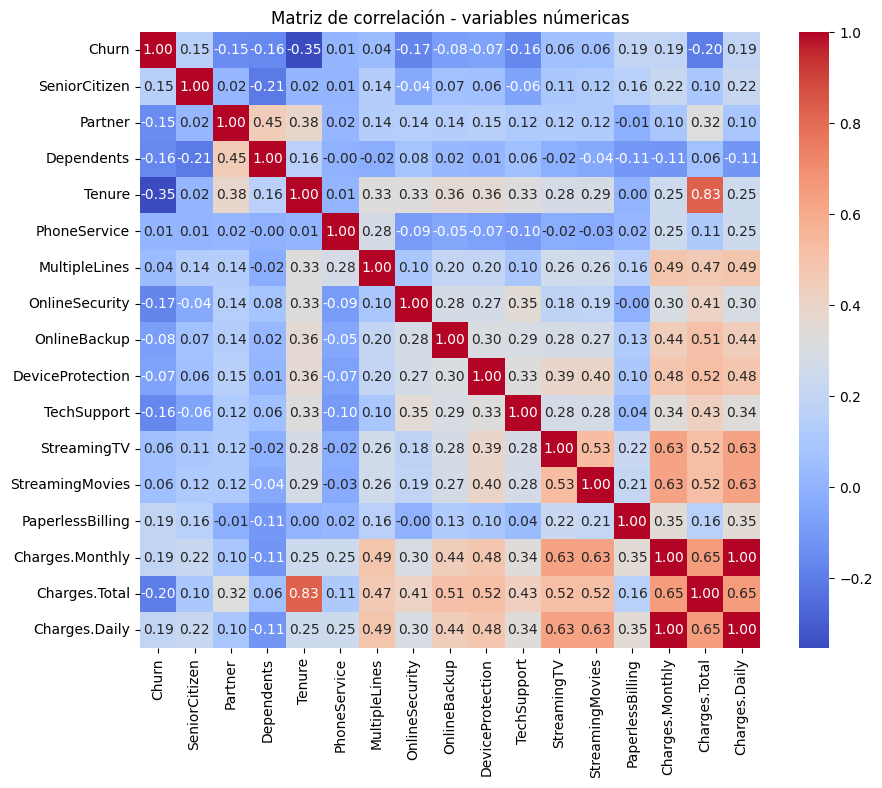

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas numéricas

df_numeric = df.select_dtypes(include=['int64', 'float64'])

# calcular matriz de correlación
corr_matrix = df_numeric.corr()

# imprimir matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación - variables númericas')
plt.show()

Podemos observar una multicolinealidad entre Tenure y Charges.Total, vamos a elegir quedarnos con Tenura que tiene más correlación con Churn. Ademas de que Charges.Total no es tan fiable como fuente, siendo que es un número dinamico que puede alterarse durante el contrato.

Por otro lado Charges.Daily y Charges.Monthly tiene una relación perfecta, lo cual es razonable porque creamos una a partir de la otra. Vamos a quedarnos con Daily.

In [115]:
df.drop(['Charges.Total', 'Charges.Monthly'], axis=1, inplace=True)
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Daily
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,2.796667


### ✔ Analisis de Churn para variables categoricas

In [116]:
# Seleccionar las columnas numéricas

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f'\nAnalisis de variable: {col}')
  display(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)



Analisis de variable: Gender


Churn,0,1
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565



Analisis de variable: InternetService


Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211



Analisis de variable: Contract


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



Analisis de variable: PaymentMethod


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


⭐ Metodo Qui-cuadrado (chi2)

In [138]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# copia del Df para hacer rank
df_rank = df.copy()

# Separar variables categoricas
categorical_cols_rank = df_rank.columns
categorical_cols_rank = categorical_cols_rank.delete(0)

# Aplicar Label encoding
le = LabelEncoder()

for col in categorical_cols_rank:
  df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y

X_cat = df_rank[categorical_cols_rank]
y_cat = df_rank['Churn']

# Aplicar test qui-cuadrado
chi_scores, p_values = chi2(X_cat, y_cat)

# Crear df con resultados
chi_df = pd.DataFrame({
    'Variable': categorical_cols_rank,
    'Chi-2': chi_scores,
    'P-valor': p_values
    })

# Ordenar por importancia
chi_df = chi_df.sort_values(by='Chi-2', ascending=False)

# Mostrar resultados
chi_df

,Variable,Chi-2,P-valor
17,Charges.Daily,78740.526254,0.000000e+00
4,Tenure,16898.537423,0.000000e+00
14,Contract,1111.759054,9.186154e-244
8,OnlineSecurity,147.165601,7.219883e-34
11,TechSupport,135.439602,2.645952e-31
1,SeniorCitizen,133.482766,7.089546e-31
3,Dependents,131.271509,2.159540e-30
15,PaperlessBilling,104.979224,1.234232e-24
2,Partner,81.857769,1.462409e-19
16,PaymentMethod,59.240507,1.395318e-14


In [143]:
significant_vars = chi_df[chi_df['P-valor'] < 0.05]

#Ranking completo
print('\nRanking completo:')
display(chi_df)


selected_features = significant_vars['Variable'].tolist()
print('\nVariables seleccionadas:')
display(significant_vars)


Ranking completo:


,Variable,Chi-2,P-valor
17,Charges.Daily,78740.526254,0.000000e+00
4,Tenure,16898.537423,0.000000e+00
14,Contract,1111.759054,9.186154e-244
8,OnlineSecurity,147.165601,7.219883e-34
11,TechSupport,135.439602,2.645952e-31
1,SeniorCitizen,133.482766,7.089546e-31
3,Dependents,131.271509,2.159540e-30
15,PaperlessBilling,104.979224,1.234232e-24
2,Partner,81.857769,1.462409e-19
16,PaymentMethod,59.240507,1.395318e-14



Variables seleccionadas:


,Variable,Chi-2,P-valor
17,Charges.Daily,78740.526254,0.000000e+00
4,Tenure,16898.537423,0.000000e+00
14,Contract,1111.759054,9.186154e-244
8,OnlineSecurity,147.165601,7.219883e-34
11,TechSupport,135.439602,2.645952e-31
1,SeniorCitizen,133.482766,7.089546e-31
3,Dependents,131.271509,2.159540e-30
15,PaperlessBilling,104.979224,1.234232e-24
2,Partner,81.857769,1.462409e-19
16,PaymentMethod,59.240507,1.395318e-14


In [145]:
df = df.drop(columns=['Gender', 'PhoneService'])

df.sample(5)

KeyError: "['Gender', 'PhoneService'] not found in axis"

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   Tenure            7032 non-null   int64  
 5   MultipleLines     7032 non-null   int64  
 6   InternetService   7032 non-null   object 
 7   OnlineSecurity    7032 non-null   int64  
 8   OnlineBackup      7032 non-null   int64  
 9   DeviceProtection  7032 non-null   int64  
 10  TechSupport       7032 non-null   int64  
 11  StreamingTV       7032 non-null   int64  
 12  StreamingMovies   7032 non-null   int64  
 13  Contract          7032 non-null   object 
 14  PaperlessBilling  7032 non-null   int64  
 15  PaymentMethod     7032 non-null   object 
 16  Charges.Daily     7032 non-null   float64
dtype

## ✂ Split

In [147]:
# 1. Separamos target de variables
X = df.drop('Churn', axis=1)
y = df['Churn'] # variable objetivo

In [148]:
from sklearn.model_selection import train_test_split

# 2. Hacemos el split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [149]:
# 3. Aplicar ONe_hot para columnas categoricas (con pandas)

# Aplicar ONe hot con pandas dummies en entreno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar ONE hoy con pandas dummies en test
X_test = pd.get_dummies(X_test, drop_first=True)

# verificar que entreno y test tengan mismas columnas
X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)


In [150]:
X_train.head(5)

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Daily,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1457,0,1,0,37,0,0,0,0,0,0,0,0,0.678333,False,True,False,False,False,False,False
7226,0,1,1,68,0,1,0,0,1,1,1,1,3.318333,True,False,False,True,False,True,False
3523,1,0,0,3,0,0,0,1,0,0,0,0,2.461667,True,False,False,False,False,True,False
4702,0,1,0,9,0,1,1,0,1,1,0,1,2.298333,False,False,False,False,False,False,True
3715,0,1,1,56,1,1,0,0,0,1,0,0,2.173333,False,False,True,False,False,False,False


In [152]:
X_test.sample(5)

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Daily,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3406,0,0,0,29,0,0,0,0,0,0,0,0,0.666667,False,True,True,False,False,False,True
4181,1,1,0,52,0,1,0,1,1,1,1,1,3.481667,True,False,True,False,False,False,False
4899,0,1,1,16,0,0,0,0,0,0,0,0,0.683333,False,True,False,True,False,False,True
4982,0,0,0,2,0,0,0,0,0,0,0,0,1.496667,False,False,False,False,False,False,False
861,0,1,1,12,0,0,0,0,0,0,0,0,0.633333,False,True,False,False,False,False,True


In [154]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1457 to 1506
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          5625 non-null   int64  
 1   Partner                                5625 non-null   int64  
 2   Dependents                             5625 non-null   int64  
 3   Tenure                                 5625 non-null   int64  
 4   MultipleLines                          5625 non-null   int64  
 5   OnlineSecurity                         5625 non-null   int64  
 6   OnlineBackup                           5625 non-null   int64  
 7   DeviceProtection                       5625 non-null   int64  
 8   TechSupport                            5625 non-null   int64  
 9   StreamingTV                            5625 non-null   int64  
 10  StreamingMovies                        5625 non-null   int64  
 11  Paperl

In [155]:
# 4. Verificar desbalanceamiento

y_train.value_counts(normalize=True) * 100

,proportion
Churn,
0,73.422222
1,26.577778


### Escalamos los datos
Para no darle mas peso a las features que esta sobre valor 1, vamos a scalarlas.

In [156]:
from sklearn.preprocessing import StandardScaler

# Escalar los datos
scaler = StandardScaler()

# OJO Hacemos fit_transform SOLO en el train
X_train_scaled = scaler.fit_transform(X_train)

# En el test SOLO hacemos transform (para no espiar el futuro)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento

### Modelo 1 : Regresión lógistica

In [171]:
# Modelo crudo

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr_raw = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr_raw))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [172]:
# Modelo con scalado de datos y balanceo de clases

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_balance = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr_balance))


              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



### Modelo Random Forest

In [166]:
# Modelo crudo
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.79      1407



In [169]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## Evaluación

### Regresión Lógistica

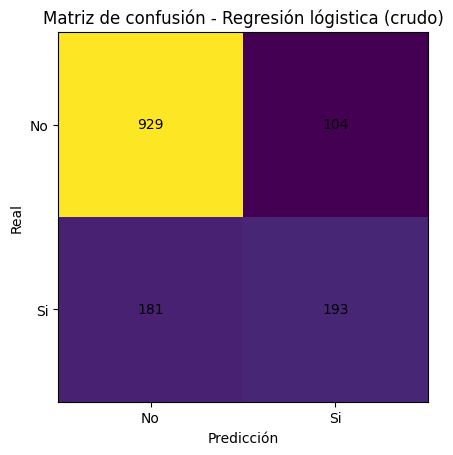

In [173]:
# Regresión lógistica crudo

from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred_lr_raw)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de confusión - Regresión lógistica (crudo)')
plt.xlabel('Predicción')
plt.ylabel('Real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks([0,1], ['No', 'Si'])
plt.yticks([0,1], ['No', 'Si'])
plt.show();

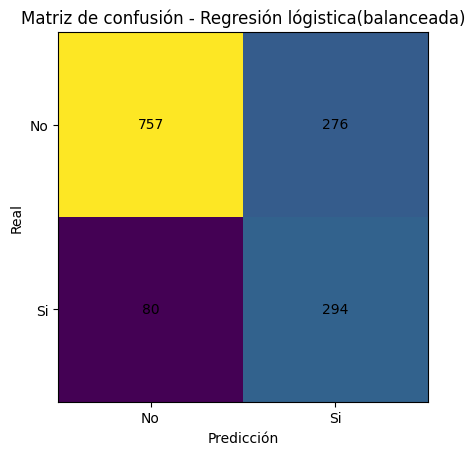

In [174]:
# Regresión Lógistica BALANCEADA

from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred_lr_balance)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de confusión - Regresión lógistica(balanceada)')
plt.xlabel('Predicción')
plt.ylabel('Real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks([0,1], ['No', 'Si'])
plt.yticks([0,1], ['No', 'Si'])
plt.show();

### Random forest

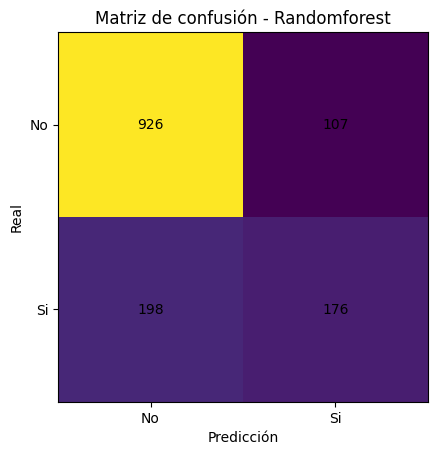

In [176]:
# rf balanceado

from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de confusión - Randomforest')
plt.xlabel('Predicción')
plt.ylabel('Real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks([0,1], ['No', 'Si'])
plt.yticks([0,1], ['No', 'Si'])
plt.show();

### Conclusiones preliminares

El modelo de ***regresion logistica (balanceado)*** mostro buenos resultados como baseline:
- 294 casos fueron etiquetados por el modelo que harian churn y lo hicieron.
- 80 casos fueron etiquetados como que no harian churn pero si lo hicieron.

Por otro lado 276 casos fueron marcados churn y en realidad no lo hicieron.

Es un costo aceptable, por ejemplo enviar un 10% de descuento a estas personas, mientras que el error fatal seria marcar clientes como no churn pero que si lo hacen.

Verdaderos Positivos: Los que se iban a ir y los detectamos: 294.
Falsos Positivos: Las "falsas alarmas": 276.
Verdaderos Negativos: Los clientes leales que no molestamos: 757
Falsos Negativos: El mayor peligro. Los que se fueron sin que nos diéramos cuenta: 80.

## 🌈 Bonus: algoritmos más potentes para datos tabulares

Hasta aqui hemos cumplido con la consigna del proyecto. Ahora vamos a hacer un último intento de conseguir mejores metricas.

Vamos a utilizar GridSearchCV para probar distintos hiperparametros de dos nuevos modelos (XGBoost y Lightgbm) y conseguir mejores metricas.

Entrenando XGBoost con GridSearchCV...
Entrenando LightGBM con GridSearchCV...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 364
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

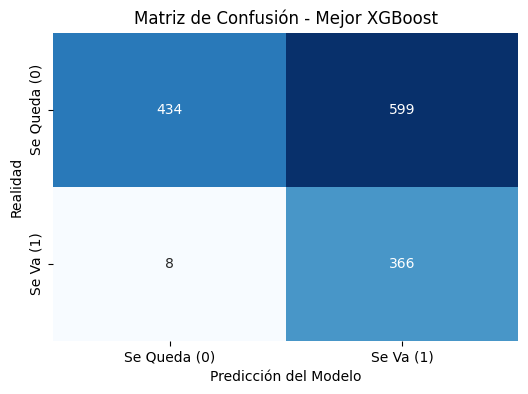

              precision    recall  f1-score   support

           0       0.98      0.42      0.59      1033
           1       0.38      0.98      0.55       374

    accuracy                           0.57      1407
   macro avg       0.68      0.70      0.57      1407
weighted avg       0.82      0.57      0.58      1407



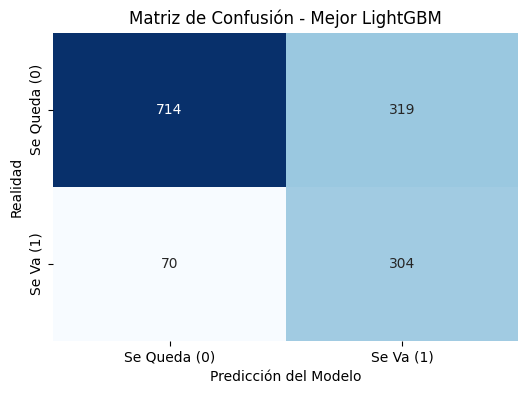

              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.81      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407



In [179]:
# Importamos las librerías necesarias
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculamos el ratio de desbalanceo para XGBoost (Cantidad de No Churn / Cantidad de Churn)
ratio_desbalanceo = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# ==========================================t5
# 1. GRID SEARCH PARA XGBOOST
# ==========================================
print("Entrenando XGBoost con GridSearchCV...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Grilla de parámetros conservadora para no tardar horas
param_grid_xgb = {
    'n_estimators': [50, 100],          # Cantidad de árboles
    'max_depth': [3, 5],                # Profundidad (3 es bueno para evitar overfitting)
    'learning_rate': [0.01, 0.1],       # Qué tan rápido aprende
    'scale_pos_weight': [ratio_desbalanceo, ratio_desbalanceo * 1.5] # Penalización para el Churn
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# ==========================================
# 2. GRID SEARCH PARA LIGHTGBM
# ==========================================
print("Entrenando LightGBM con GridSearchCV...")
lgbm = LGBMClassifier(random_state=42, class_weight='balanced')

param_grid_lgbm = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=5, scoring='recall', n_jobs=-1)
grid_lgbm.fit(X_train, y_train)

# ==========================================
# 3. EVALUACIÓN Y MATRIZ DE CONFUSIÓN
# ==========================================
# Obtenemos los mejores modelos
best_xgb = grid_xgb.best_estimator_
best_lgbm = grid_lgbm.best_estimator_

# Predicciones
y_pred_xgb = best_xgb.predict(X_test)
y_pred_lgbm = best_lgbm.predict(X_test)

print("\n--- MEJORES PARÁMETROS ---")
print(f"XGBoost: {grid_xgb.best_params_}")
print(f"LightGBM: {grid_lgbm.best_params_}\n")

# Función para graficar la Matriz
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Se Queda (0)', 'Se Va (1)'],
                yticklabels=['Se Queda (0)', 'Se Va (1)'])
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Realidad')
    plt.title(title)
    plt.show()
    print(classification_report(y_true, y_pred))

# Graficamos ambos
plot_confusion_matrix(y_test, y_pred_xgb, 'Matriz de Confusión - Mejor XGBoost')
plot_confusion_matrix(y_test, y_pred_lgbm, 'Matriz de Confusión - Mejor LightGBM')

## Conclusiones finales



### 📊 Insights del Análisis Exploratorio (EDA)
Durante la fase exploratoria se descubrieron patrones clave de comportamiento:
* **El factor "Tenure":** A mayor antigüedad del cliente, la probabilidad de fuga disminuye drásticamente.
* **El factor "Contrato":** Existe una fuerte correlación positiva entre las cancelaciones y los clientes que poseen contratos de renovación mensual (`Month-to-month`). Estos clientes son los más volátiles y el principal foco de alerta.
* **El factor edad**: Los clientes senior tiene el doble de probabilidad de hacer churn.
* **El factor soltero**: Clientes sin pareja son mas propicios a hacer churn.
* **El factor fibraoptica**: Clientes con este tipo de servicio tiene más tendencia a hacer churn.

### 🏆 Modelo seleccionado: Lightgbm

El modelo lightgbm fue el que mejor se desesmpeño para el problema de predecir si un cliente iba a realizar churn o no.

Marco 70 clientes como que no iban a hacer churn y lo hicieron. Fue superado por el XGBoost, pero este se volvio conservador y comenzo a etiquetar todo como posible fuga, lo cual limita las posibles estrategias como otorgar descuentos para lograr la retención.

**LightGBM** fue seleccionado como el modelo final. Logró un excelente equilibrio para el negocio: un **Recall del 81%** (atrapando a 8 de cada 10 desertores) manteniendo los Falsos Positivos en un margen comercialmente aceptable, superando la tendencia al sobreajuste detectada en XGBoost.